#🫀 Wykrywanie wad serca wykorzystując regresję logistyczną.

Zadaniem projektu jest implementacja algorytmu regresji logistycznej. Na podstawie zbioru badań prognozowane będą przypadki wystąpienia chorób serca. Problem został sformułowany w postaci klasyfikacji binarnej (podział na osoby chore i zdrowe). Do nauki algorytmu wykorzystano dataset z [repozytorium UCI.]( https://archive.ics.uci.edu/dataset/45/heart+disease)


---


 Projekt ma na celu wykorzystanie algorytmu napisanego samodzielnie, bez pomocy zewnętrznych bibliotek. Algorytm zostanie poddany ewaluacji oraz porównany z innymi narzędziami wykorzystywanymi do klasyfikacji (knn, drzewo decyzyjne, las losowy). Sprawdzane będą następujące metryki:


*   Dokładność (*Accuracy*)
*   Czułość (*Recall*)
*   Precyzja (*Precision*)
*   ROC-AUC



# 📁 Sekcja 1: Przygotowanie projektu i danych

In [ ]:
import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Path to dataset files:", path)
data = pd.read_csv(f"{path}/heart.csv")

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Path to dataset files: /kaggle/input/heart-disease-dataset


# 📊 Sekcja 2: Analiza danych

Podstawowe statystyki zbioru danych.

In [ ]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Opis danych

cp – typ bólu w klatce piersiowej

Określa charakter bólu, co jest jednym z najsilniejszych sygnałów diagnostycznych. Dławica typowa (0) mocno wskazuje na niedokrwienie serca, natomiast ból atypowy lub brak objawów może oznaczać trudniejsze do wykrycia przypadki lub inne źródła bólu.

---

trestbps – ciśnienie krwi w spoczynku

Wysokie ciśnienie (nadciśnienie) uszkadza naczynia krwionośne i przyspiesza rozwój miażdżycy, co bezpośrednio zwiększa ryzyko chorób serca.

---

chol – cholesterol w surowicy

Wysoki poziom cholesterolu sprzyja odkładaniu blaszek miażdżycowych w tętnicach, co prowadzi do zwężenia naczyń wieńcowych.

---

fbs – cukier na czczo

Podwyższony poziom glukozy sugeruje cukrzycę lub insulinooporność, które silnie zwiększają ryzyko chorób sercowo-naczyniowych poprzez uszkodzenie naczyń.

---

restecg – spoczynkowe EKG

Pokazuje elektryczną aktywność serca — może wykrywać niedokrwienie, arytmie lub przerost mięśnia sercowego.

---

thalach – maksymalne tętno

Niskie maksymalne tętno osiągane podczas wysiłku może wskazywać na ograniczoną wydolność serca lub niedokrwienie.

---

exang – dławica wywołana wysiłkiem

Silny marker choroby wieńcowej — jeśli wysiłek wywołuje ból, oznacza to, że serce nie dostaje wystarczającej ilości tlenu.

---

oldpeak – obniżenie odcinka ST

Im większe obniżenie ST, tym większe prawdopodobieństwo niedokrwienia mięśnia sercowego (jak bardzo ST spada).

---

slope – nachylenie ST

Opisuje reakcję serca na wysiłek — opadający slope często wskazuje na gorsze ukrwienie (jak ST się zachowuje przy wysiłku).

---

ca – liczba naczyń wieńcowych

Im więcej zajętych naczyń, tym bardziej zaawansowana choroba wieńcowa.

---

thal – wynik testu radioizotopowego

Pokazuje, czy część mięśnia sercowego jest niedokrwiona (defekt odwracalny) lub martwa (stały defekt).

### Usuwanie duplikatów i wykresy

Usuwanie duplikatów

In [ ]:
data.duplicated().sum()

np.int64(723)

In [ ]:
data = data.drop_duplicates()

Usuwanie wierszy w których nie ma danych

In [ ]:
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Sprawdzanie rozkładu danych

In [ ]:
data['target'].value_counts()

,count
target,
1,164
0,138


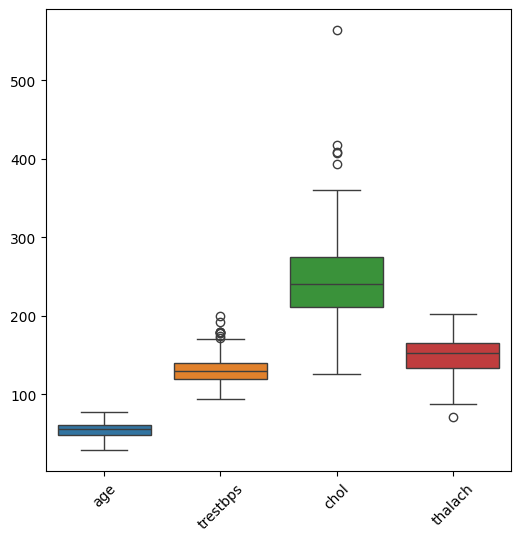

In [ ]:
plt.figure(figsize=(6,6))
sns.boxplot(data=data[["age", "trestbps", "chol", "thalach"]])

plt.xticks(rotation=45)
plt.show()

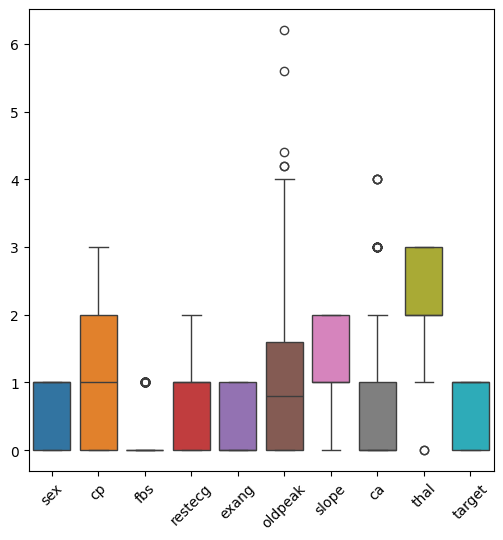

In [ ]:
plt.figure(figsize=(6,6))
sns.boxplot(data=data[["sex", "cp", "fbs", "restecg", "exang", "oldpeak", "slope", "ca", "thal", "target"]])

plt.xticks(rotation=45)
plt.show()

Sprawdzanie korelacji cech

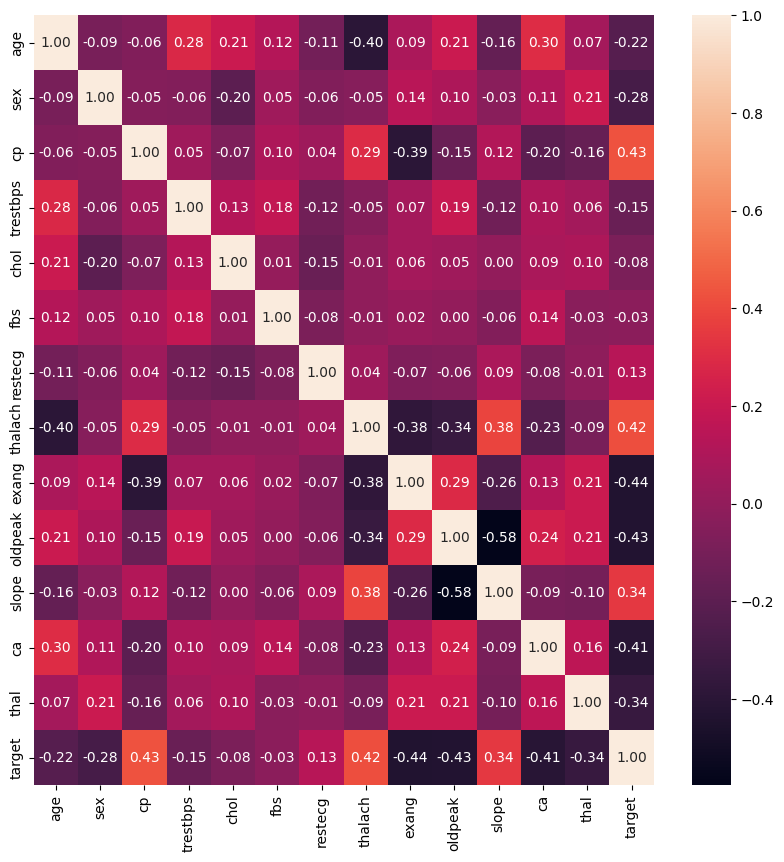

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(), annot=True, fmt=".2f")


plt.show()

Podział zbioru danych na zbiór uczący i sprawdzający

In [ ]:
def split_dataset(data, f=0.8):
  train_set = data.sample(frac=f, random_state=42)

  test_set = data.drop(train_set.index)

  X_train = train_set.drop('target', axis=1)
  y_train = train_set['target']
  X_test = test_set.drop('target', axis=1)
  y_test = test_set['target']

  return X_train, y_train, X_test, y_test

In [ ]:
X_train, y_train, X_test, y_test = split_dataset(data)

# Sekcja 3: Implementacja algorttmu regresji logistycznej

In [ ]:
def sigmoid(z):
  return 1/(1 + np.exp(-z))

def calculate_gradient(X, y, theta):
  m = y.size
  return (X.T @ (sigmoid(X @ theta) - y)) / m

def cost_function(X, y, theta):
  m = X.shape[0]

  h = sigmoid(X @ theta)
  epsilon = 1e-15
  h = np.clip(h, epsilon, 1)

  cost_sum = -y @ np.log(h) - (1-y) @ np.log(1 - h)

  return (1/m)*cost_sum

def gradient_descent(X, y, alpha=0.1, num_iter=100, tol=1e-7):
  X_b = np.c_[np.ones((X.shape[0], 1)), X]
  theta = np.zeros(X_b.shape[1])

  cst = []
  iter = []
  for i in range(num_iter):
    if i % 10000 == 0:
      c = cost_function(X_b, y, theta)
      iter.append(i)
      cst.append(c)

      #print(f"Iteration: {i} cost function equals: {c}")

    gradient = calculate_gradient(X_b, y, theta)
    theta -= alpha * gradient

    if np.linalg.norm(alpha * gradient) < tol:
      break


  return theta, [iter, cst]

def predict(X, theta, threshold=0.5):
  X_b = np.c_[np.ones((X.shape[0], 1)), X]
  predict_prob = sigmoid(X_b @ theta)

  return (predict_prob >= threshold).astype(int)

# Sekcja 4: Implementacja metryk i wykresów


In [ ]:
def confussion_matrix(y_pred, y_target):
  conf_mat = np.zeros((2, 2), dtype=int)

  for i in range(len(y_target)):
    if y_pred[i] == 1 and y_target[i] == 1:
      conf_mat[0, 0] += 1
    elif y_pred[i] == 0 and y_target[i] == 1:
      conf_mat[0, 1] += 1
    elif y_pred[i] == 1 and y_target[i] == 0:
      conf_mat[1, 0] += 1
    else:
      conf_mat[1, 1] += 1

  return conf_mat

def accuracy(conf_mat):
  return (conf_mat[0, 0] + conf_mat[1, 1]) / conf_mat.sum()

def recall(conf_matrix):
  return (conf_matrix[0, 0]) / (conf_matrix[0, 0] + conf_matrix[0, 1])

def precision(conf_matrix):
  return (conf_matrix[0, 0]) / (conf_matrix[0, 0] + conf_matrix[1, 0])

def false_positive_rate(conf_matrix):
  return (conf_matrix[1, 0]) / (conf_matrix[1, 0] + conf_matrix[1, 1])

In [ ]:
def plot_confusion_matrix(cm,
                          title='Macierz pomyłek',
                          cmap=plt.cm.Blues):

  plt.figure(figsize=(7,5))

  labels = np.array([
    [f"TP\n{cm[0,0]}", f"FN\n{cm[0,1]}"],
    [f"FP\n{cm[1,0]}", f"TN\n{cm[1,1]}"]
  ])


  sns.heatmap(
      cm,
      annot=labels,
      fmt="",
      cmap=cmap,
      xticklabels=False,
      yticklabels=False
  )

  plt.title(title)
  plt.xlabel("Predykcje")
  plt.ylabel("Wartość prawdziwa")

  plt.show()

In [ ]:
def roc_curve(y_target, X, theta, ths=10):
  tpr = []
  fpr = []
  thresholds = np.linspace(0, 1, ths)

  for threshold in thresholds:
    predictions = predict(X, theta, threshold)
    cm = confussion_matrix(predictions, y_target)
    tpr.append(recall(cm))
    fpr.append(false_positive_rate(cm))

  return tpr, fpr

In [ ]:
def plot_cost_function(cost_data):
  plt.figure(figsize=(8,6))
  plt.plot(cost_data[0], cost_data[1])
  plt.xlabel("Liczba iteracji")
  plt.ylabel("Funkcja kosztu")
  plt.title("Wykres funkcji kosztu")
  plt.show()

In [ ]:
def plot_k_fold_comparison(accuracy_list, shapes=["Empty"]):
  if shapes == ["Empty"]:
    shapes =  [f"Fold {i+1}" for i in range(len(accuracy_list))]

  plt.figure(figsize=(8, 5))

  bars = plt.bar(
      shapes,
      accuracy_list,
      edgecolor='black',
      linewidth=1.2
  )

  # wartości nad słupkami
  for bar in bars:
      height = bar.get_height()
      plt.text(
          bar.get_x() + bar.get_width()/2,
          height - 5,
          f'{height:.1f}%',
          ha='center',
          fontsize=10
      )

  plt.title("Porównanie Accuracy dla różnego podziału danych", fontsize=16)
  plt.xlabel("Fold", fontsize=12)
  plt.ylabel("Accuracy [%]", fontsize=12)

  plt.ylim(0, 100)

  plt.grid(axis='y', linestyle='--', alpha=0.7)

  plt.tight_layout()
  plt.show()

In [ ]:
def plot_roc_curve(tpr_tab, fpr_tab, names):
  plt.figure(figsize=(8,6))

  for i in range(len(tpr_tab)):
    auc = abs(np.trapezoid(tpr_tab[i], fpr_tab[i]))
    plt.plot(fpr_tab[i], tpr_tab[i], linewidth=2, label=f"{names[i]}. Auc = {auc:.3f}")

  plt.plot([0,1], [0,1], linestyle="--", label="Klasyfikator losowy")

  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("Wykres ROC")

  plt.legend(loc="lower right")
  plt.grid(alpha=0.3)

  plt.show()

In [ ]:
def plot_k_fold_comparison_recall(recall_list, shapes=["Empty"]):
  if shapes == ["Empty"]:
    shapes =  [f"Fold {i+1}" for i in range(len(recall_list))]

  plt.figure(figsize=(8, 5))

  bars = plt.bar(
      shapes,
      recall_list,
      edgecolor='black',
      linewidth=1.2
  )

  # wartości nad słupkami
  for bar in bars:
      height = bar.get_height()
      plt.text(
          bar.get_x() + bar.get_width()/2,
          height - 5,
          f'{height:.1f}%',
          ha='center',
          fontsize=10
      )

  plt.title("Porównanie Recall dla różnego podziału danych", fontsize=16)
  plt.xlabel("Fold", fontsize=12)
  plt.ylabel("Recall [%]", fontsize=12)

  plt.ylim(0, 100)

  plt.grid(axis='y', linestyle='--', alpha=0.7)

  plt.tight_layout()
  plt.show()

# Sekcja 5: Badanie włąsnego algorytmu oraz porównanie z regresją logistyczną z biblioteki sklearn.learn

In [ ]:
# Słownik agregujący wyniki wszystkich eksperymentów
results = {}

## 5.1. Własny algorytm

Zbieranie pomiarów

In [ ]:
theta_hat, cost_data = gradient_descent(X_train, y_train, alpha=0.0001, num_iter=150000)
predictions = predict(X_test, theta_hat, 0.45)
cm = confussion_matrix(predictions, y_test.values)
tpr, fpr = roc_curve(y_test.values, X_test.values, theta_hat, 100)

results["Log_reg"] = {
    "Theta": theta_hat,
    "cost_data": cost_data,
    "Confusion_matrix": cm,
    "TPR": tpr,
    "FPR": fpr,
    "Stats": {
      "Accuracy": round(float(accuracy(cm)*100), 2),
      "Recall": round(float(recall(cm)*100), 2),
      "Precision": round(float(precision(cm)*100), 2),
      "FPR": round(float(false_positive_rate(cm)*100), 2)
      }
}

Wykresy

In [ ]:
results["Log_reg"]["Stats"]

{'Accuracy': 85.0, 'Recall': 96.97, 'Precision': 80.0, 'FPR': 29.63}

Macierz pomyłek:

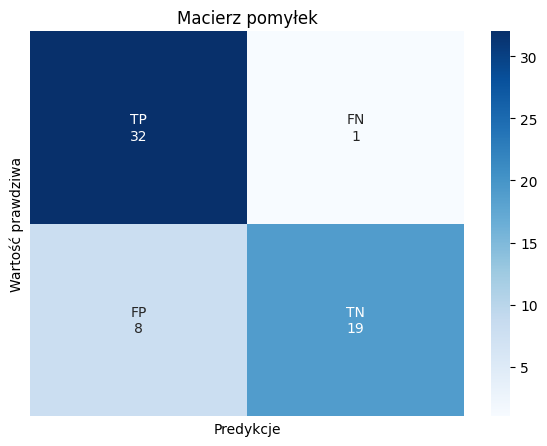

In [ ]:
plot_confusion_matrix(results["Log_reg"]["Confusion_matrix"])

Krzywa uczenia:

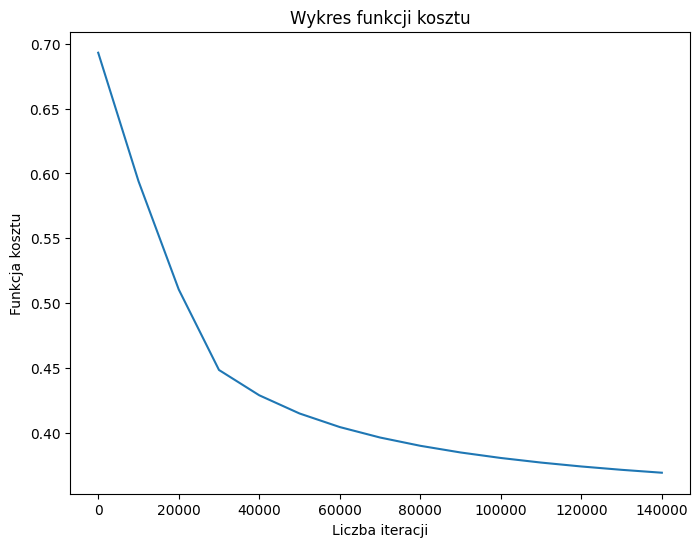

In [ ]:
plot_cost_function(results["Log_reg"]["cost_data"])

Krzywa ROC

In [ ]:
tpr_tab, fpr_tab, names = [], [], []

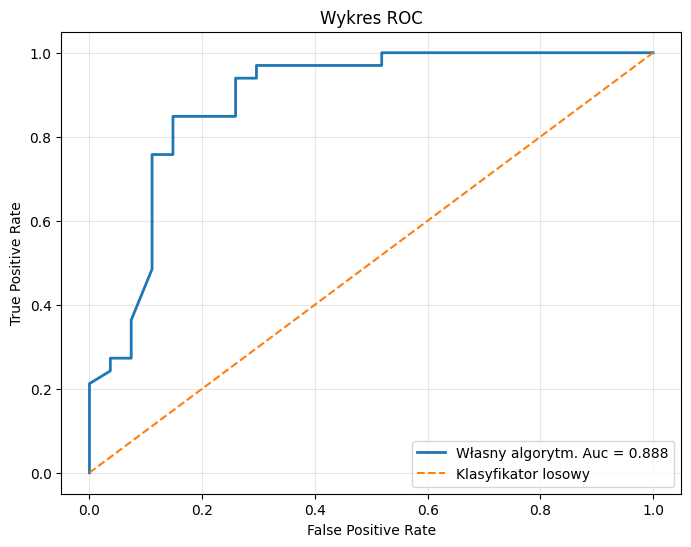

In [ ]:
if "Własny algorytm" not in names:
  tpr_tab.append(results["Log_reg"]["TPR"])
  fpr_tab.append(results["Log_reg"]["FPR"])
  names.append("Własny algorytm")

plot_roc_curve(tpr_tab, fpr_tab, names)

## 5.2. Rozwiązywanie problemu ograniczonej ilości danych

### K-Fold Cross-Validation

In [ ]:
from math import floor

k = 8
batch_size = floor(data.shape[0]/k)
accuracy_list = []
recall_list = []
shapes = []

for fold in range(k-1):
  if fold == k-2:
    test_set = data.iloc[fold*batch_size:]
    shapes.append(f"[{fold*batch_size}:{fold*batch_size + test_set.shape[0]}]")
  else:
    test_set = data.iloc[fold*batch_size:fold*batch_size + 2*batch_size]
    shapes.append(f"[{fold*batch_size}:{fold*batch_size + 2*batch_size}]")
  train_set = data.drop(test_set.index)

  X_train = train_set.drop('target', axis=1).to_numpy()
  y_train = train_set['target'].to_numpy()
  X_test = test_set.drop('target', axis=1).to_numpy()
  y_test = test_set['target'].to_numpy()

  theta_hat, cost_data = gradient_descent(X_train, y_train, alpha=0.0001, num_iter=150000)
  predictions = predict(X_test, theta_hat, 0.45)
  acc = np.mean(predictions == y_test)*100
  accuracy_list.append(acc)
  print(f"Fold: {fold + 1}. Accuracy: {acc}")

  cm = confussion_matrix(predictions, y_test)
  recall_list.append(recall(cm)*100)

Fold: 1. Accuracy: 81.08108108108108
Fold: 2. Accuracy: 82.43243243243244
Fold: 3. Accuracy: 82.43243243243244
Fold: 4. Accuracy: 89.1891891891892
Fold: 5. Accuracy: 91.8918918918919
Fold: 6. Accuracy: 85.13513513513513
Fold: 7. Accuracy: 77.5


ACCURACY

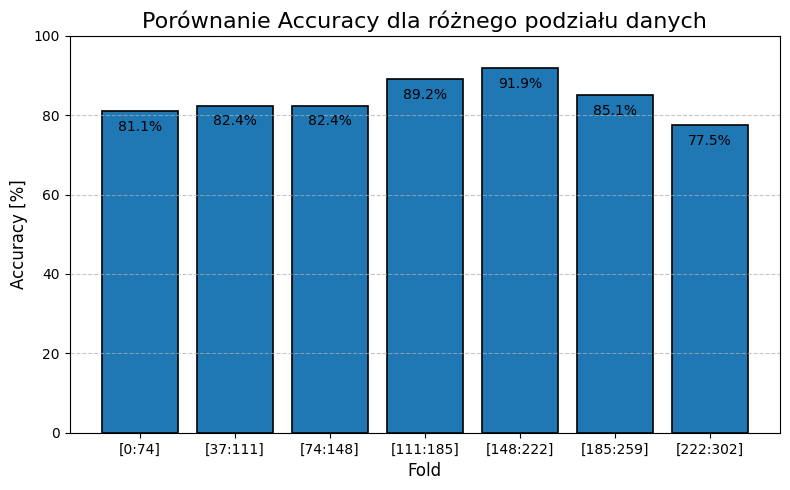

In [ ]:
plot_k_fold_comparison(accuracy_list, shapes)

RECALL

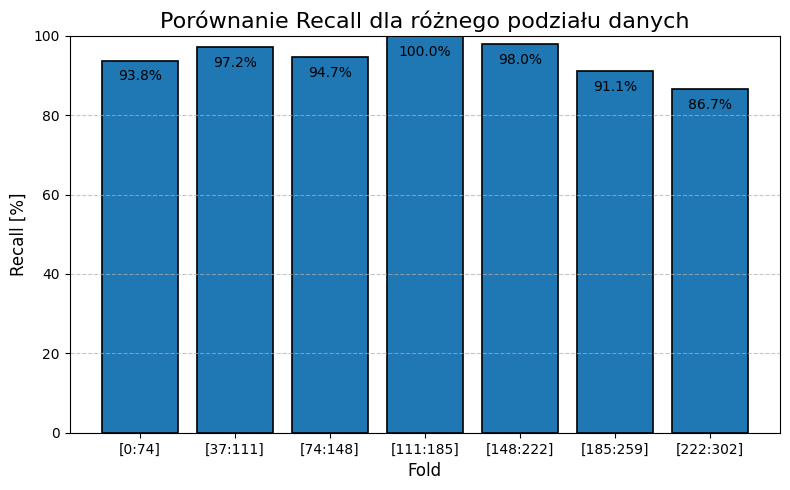

In [ ]:
plot_k_fold_comparison_recall(recall_list, shapes)

### Dodawanie syntetycznych danych

In [ ]:
X_train, y_train, X_test, y_test = split_dataset(data, 0.7)

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((211, 13), (211,), (91, 13), (91,))

In [ ]:
continous_data = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_data = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

noise_fraction = 0.1
target_total_samples = 1000
samples_to_add = target_total_samples - X_train.shape[0]

std = X_train[continous_data].std()
new_X_rows = []
new_y_rows = []

if samples_to_add > 0:
    random_indices = np.random.choice(X_train.shape[0], size=samples_to_add, replace=True)

    for i in random_indices:
        new_data = X_train.iloc[i].copy()
        original_label = y_train.iloc[i]

        for col in continous_data:
            noise = np.random.normal(0, std[col] * noise_fraction)
            if col == 'age':
                new_data[col] = round(new_data[col] + noise)
            elif col == 'ca':
                new_data[col] = np.clip(round(new_data[col] + noise), 0, None)
            else:
                new_data[col] += noise

        new_X_rows.append(new_data)
        new_y_rows.append(original_label)

    new_X_df = pd.DataFrame(new_X_rows)
    new_y_series = pd.Series(new_y_rows, name=y_train.name if hasattr(y_train, 'name') else 'target')
    X_train_augmented = pd.concat([X_train, new_X_df], ignore_index=True)
    y_train_augmented = pd.concat([y_train, new_y_series], ignore_index=True)
else:
    print("Zbiór ma już pożądaną wielkość!")

print(f"Rozmiar końcowy: {X_train_augmented.shape[0]}")

Rozmiar końcowy: 1000


Testowanie

In [ ]:
theta_hat, cost_data = gradient_descent(X_train_augmented, y_train_augmented, alpha=0.0001, num_iter=150000)
predictions = predict(X_test, theta_hat, 0.45)
cm = confussion_matrix(predictions, y_test.values)
tpr, fpr = roc_curve(y_test.values, X_test.values, theta_hat, 100)

results["Log_reg_aug"] = {
    "Theta": theta_hat,
    "cost_data": cost_data,
    "Confusion_matrix": cm,
    "TPR": tpr,
    "FPR": fpr,
    "Stats": {
      "Accuracy": round(float(accuracy(cm)*100), 2),
      "Recall": round(float(recall(cm)*100), 2),
      "Precision": round(float(precision(cm)*100), 2),
      "FPR": round(float(false_positive_rate(cm)*100), 2)
      }
}

Wykresy

In [ ]:
results["Log_reg_aug"]["Stats"]

{'Accuracy': 84.62, 'Recall': 98.08, 'Precision': 79.69, 'FPR': 33.33}

Macierz pomyłek:

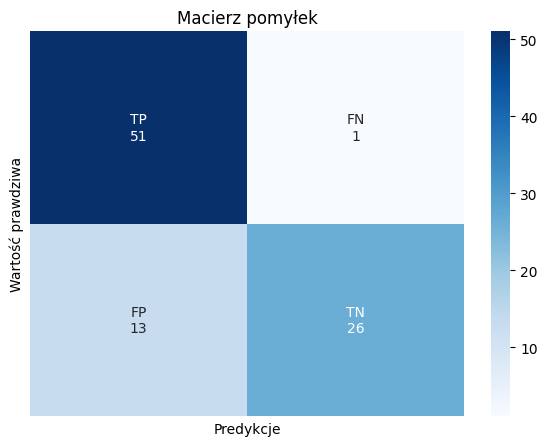

In [ ]:
plot_confusion_matrix(results["Log_reg_aug"]["Confusion_matrix"])

Krzywa uczenia:

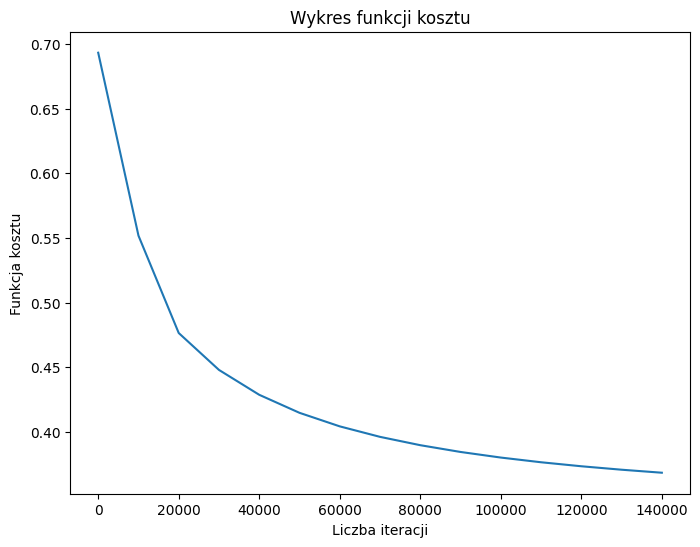

In [ ]:
plot_cost_function(results["Log_reg_aug"]["cost_data"])

Krzywa ROC

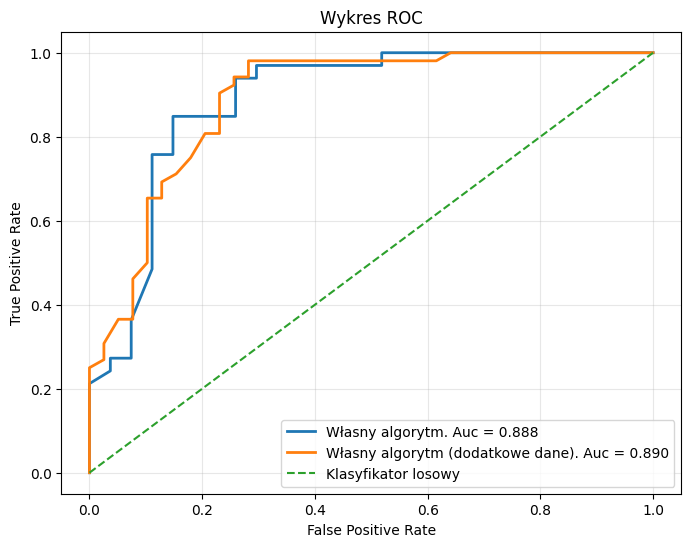

In [ ]:
plot_roc_curve(tpr_tab + [results["Log_reg_aug"]["TPR"]],
               fpr_tab + [results["Log_reg_aug"]["FPR"]],
               names + ["Własny algorytm (dodatkowe dane)"])

## 5.3. Model z sklearn

In [ ]:
X_train, y_train, X_test, y_test = split_dataset(data)

Testowanie

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state=16, max_iter=150000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
cm = confussion_matrix(y_pred, y_test.values)

tpr = []
fpr = []
thresholds = np.linspace(0, 1, 100)

for threshold in thresholds:
  predictions = (logreg.predict_proba(X_test)[:,1] > threshold).astype(int)
  cm_s = confussion_matrix(predictions, y_test.values)
  tpr.append(recall(cm_s))
  fpr.append(false_positive_rate(cm_s))

results["Log_reg_sklearn"] = {
    "Theta": logreg.coef_,
    "Confusion_matrix": cm,
    "TPR": tpr,
    "FPR": fpr,
    "Stats": {
      "Accuracy": round(float(accuracy(cm)*100), 2),
      "Recall": round(float(recall(cm)*100), 2),
      "Precision": round(float(precision(cm)*100), 2),
      "FPR": round(float(false_positive_rate(cm)*100), 2)
      }
}

Wyniki

In [ ]:
results["Log_reg_sklearn"]["Stats"]

{'Accuracy': 81.67, 'Recall': 90.91, 'Precision': 78.95, 'FPR': 29.63}

Macierz pomyłek

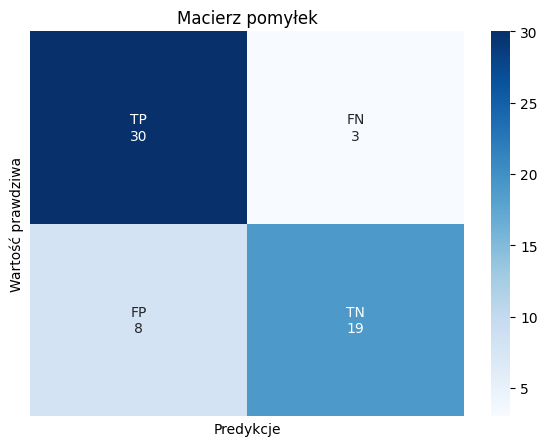

In [ ]:
plot_confusion_matrix(results["Log_reg_sklearn"]["Confusion_matrix"])

ROC curve

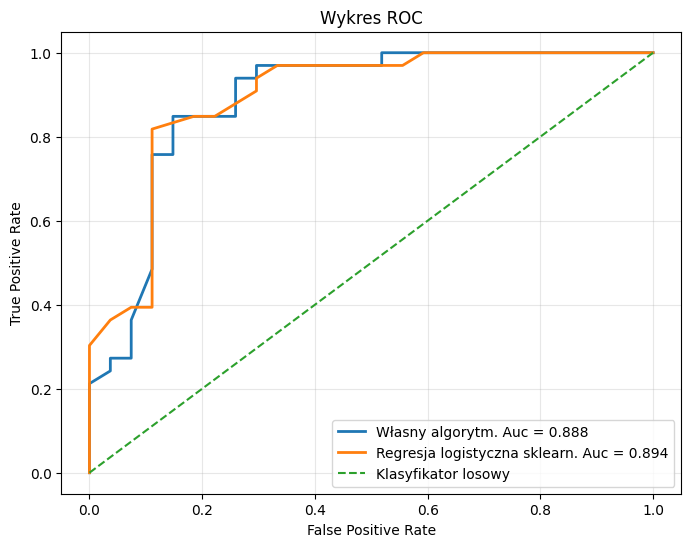

In [ ]:
if "Regresja logistyczna sklearn" not in names:
  tpr_tab.append(results["Log_reg_sklearn"]["TPR"])
  fpr_tab.append(results["Log_reg_sklearn"]["FPR"])
  names.append("Regresja logistyczna sklearn")
plot_roc_curve(tpr_tab, fpr_tab, names)

# Sekcja 6: Porównanie regresji logistycznej z innymi algorytmami

In [ ]:
import sklearn.metrics as skm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 6.1. K najbliższych sąsiadów

Testy

In [ ]:
neigh = KNeighborsClassifier(n_neighbors=8)
neigh.fit(X_train, y_train)

y_pred = neigh.predict(X_test)
cm = confussion_matrix(y_pred, y_test.values)
y_prob = neigh.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = skm.roc_curve(y_test, y_prob)

results["KNN"] = {
    "Confusion_matrix": cm,
    "TPR": tpr,
    "FPR": fpr,
    "Stats": {
      "Accuracy": round(float(accuracy(cm)*100), 2),
      "Recall": round(float(recall(cm)*100), 2),
      "Precision": round(float(precision(cm)*100), 2),
      "FPR": round(float(false_positive_rate(cm)*100), 2)
      }
}

Wyniki

In [ ]:
results["KNN"]["Stats"]

{'Accuracy': 75.0, 'Recall': 75.76, 'Precision': 78.12, 'FPR': 25.93}

Macierz pomyłek

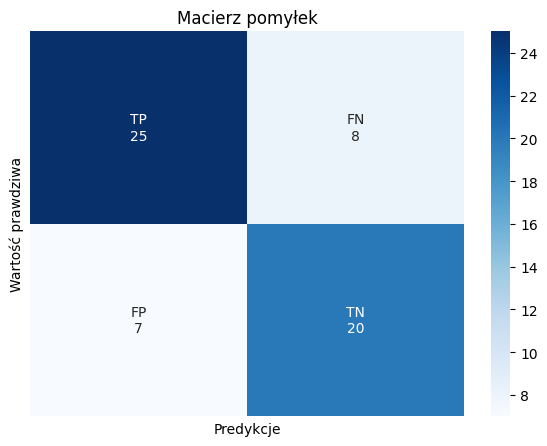

In [ ]:
plot_confusion_matrix(results["KNN"]["Confusion_matrix"])

ROC curve

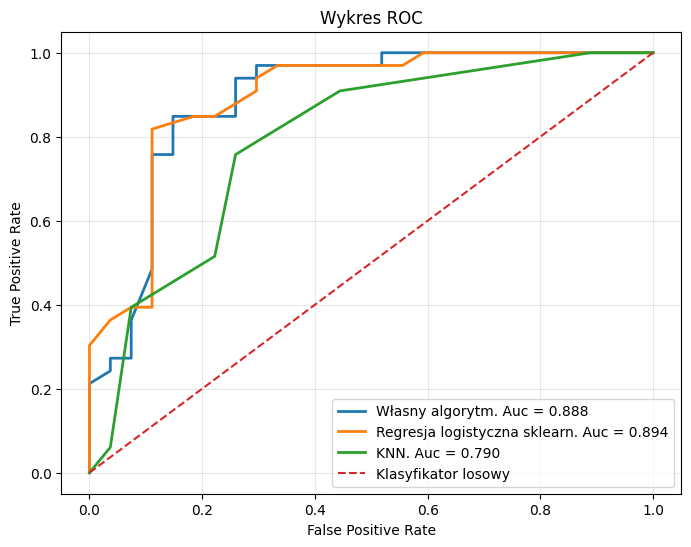

In [ ]:
if "KNN" not in names:
  tpr_tab.append(results["KNN"]["TPR"])
  fpr_tab.append(results["KNN"]["FPR"])
  names.append("KNN")
plot_roc_curve(tpr_tab, fpr_tab, names)

## 6.2. Drzewo decyzyjne

Testy

In [ ]:
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
cm = confussion_matrix(y_pred, y_test.values)
y_prob = tree.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = skm.roc_curve(y_test, y_prob)

results["Decision_tree"] = {
    "Confusion_matrix": cm,
    "TPR": tpr,
    "FPR": fpr,
    "Stats": {
      "Accuracy": round(float(accuracy(cm)*100), 2),
      "Recall": round(float(recall(cm)*100), 2),
      "Precision": round(float(precision(cm)*100), 2),
      "FPR": round(float(false_positive_rate(cm)*100), 2)
      }
}

Wyniki

In [ ]:
results["Decision_tree"]["Stats"]

{'Accuracy': 80.0, 'Recall': 90.91, 'Precision': 76.92, 'FPR': 33.33}

Macierz pomyłek

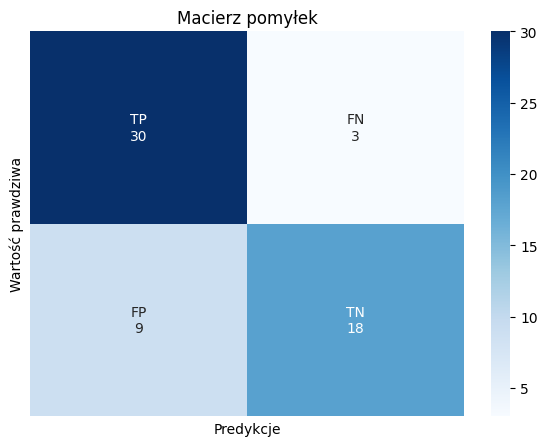

In [ ]:
plot_confusion_matrix(results["Decision_tree"]["Confusion_matrix"])

ROC curve

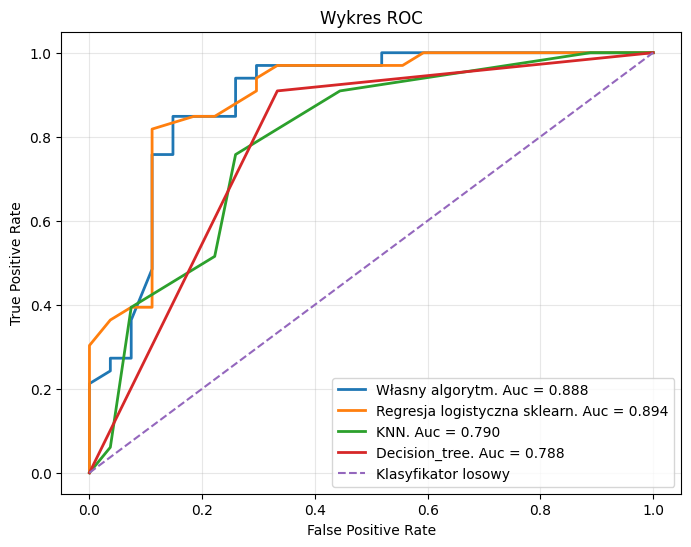

In [ ]:
if "Decision_tree" not in names:
  tpr_tab.append(results["Decision_tree"]["TPR"])
  fpr_tab.append(results["Decision_tree"]["FPR"])
  names.append("Decision_tree")
plot_roc_curve(tpr_tab, fpr_tab, names)

## 6.3. Las losowy

Testy

In [ ]:
forest = RandomForestClassifier(random_state=0)
forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)
cm = confussion_matrix(y_pred, y_test.values)
y_prob = forest.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = skm.roc_curve(y_test, y_prob)

results["Random_forest"] = {
    "Confusion_matrix": cm,
    "TPR": tpr,
    "FPR": fpr,
    "Stats": {
      "Accuracy": round(float(accuracy(cm)*100), 2),
      "Recall": round(float(recall(cm)*100), 2),
      "Precision": round(float(precision(cm)*100), 2),
      "FPR": round(float(false_positive_rate(cm)*100), 2)
      }
}

Wyniki

In [ ]:
results["Random_forest"]["Stats"]

{'Accuracy': 81.67, 'Recall': 87.88, 'Precision': 80.56, 'FPR': 25.93}

Macierz pomyłek

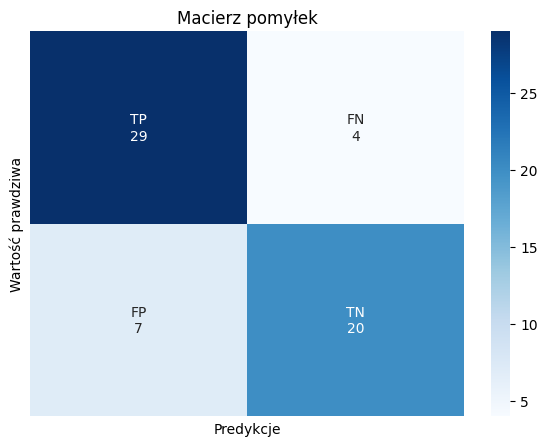

In [ ]:
plot_confusion_matrix(results["Random_forest"]["Confusion_matrix"])

ROC curve

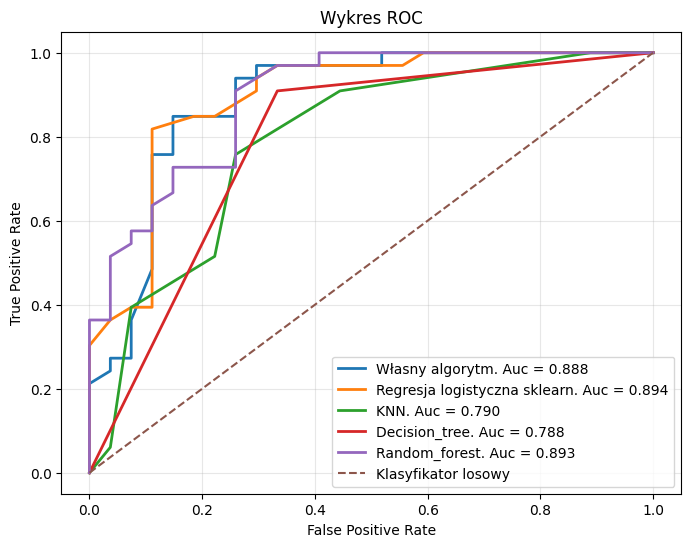

In [ ]:
if "Random_forest" not in names:
  tpr_tab.append(results["Random_forest"]["TPR"])
  fpr_tab.append(results["Random_forest"]["FPR"])
  names.append("Random_forest")
plot_roc_curve(tpr_tab, fpr_tab, names)